# Notebook 4: Exploratory Data Analysis

This notebook examines historical patterns in electric vehicle adoption and charging infrastructure. The analysis addresses national trends across the United Kingdom and regional differences across England and Wales, where compatible geographical lookup and population data are available.

The exploratory analysis focuses on changes over time, differences between vehicle and keepership categories, regional variation, population-adjusted adoption and the relationship between EV uptake and public charging infrastructure.

In [1]:
from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)

print("Libraries imported successfully.")

Libraries imported successfully.


## Project Folders and Dataset Locations

The processed and integrated datasets are loaded from the project folders. The complete cleaned EV dataset is used for UK-level trend analysis, while the integrated England and Wales dataset is used for regional analysis.

In [2]:
project_folder = Path.cwd().parent

processed_folder = project_folder / "Datasets" / "processed"
figures_folder = project_folder / "Figures"
tables_folder = project_folder / "Tables"

figures_folder.mkdir(parents=True, exist_ok=True)
tables_folder.mkdir(parents=True, exist_ok=True)

print("Processed folder exists:", processed_folder.exists())
print("Figures folder exists:", figures_folder.exists())
print("Tables folder exists:", tables_folder.exists())

Processed folder exists: True
Figures folder exists: True
Tables folder exists: True


In [3]:
ev_uk = pd.read_csv(
    processed_folder / "ev_clean.csv",
    low_memory=False
)

ev_regional = pd.read_csv(
    processed_folder / "ev_integrated.csv",
    low_memory=False
)

charging_data = pd.read_csv(
    processed_folder / "charging_clean.csv",
    low_memory=False
)

print("UK EV dataset:", ev_uk.shape)
print("Regional integrated dataset:", ev_regional.shape)
print("Charging dataset:", charging_data.shape)

UK EV dataset: (285505, 62)
Regional integrated dataset: (247667, 66)
Charging dataset: (433, 29)


In [4]:
print("UK EV columns:")
print(ev_uk.columns.tolist())

print("\nRegional dataset columns:")
print(ev_regional.columns.tolist())

print("\nCharging columns:")
print(charging_data.columns.tolist())

UK EV columns:
['LSOA21CD', 'LSOA21NM', 'Fuel', 'Keepership', '2026 Q1', '2025 Q4', '2025 Q3', '2025 Q2', '2025 Q1', '2024 Q4', '2024 Q3', '2024 Q2', '2024 Q1', '2023 Q4', '2023 Q3', '2023 Q2', '2023 Q1', '2022 Q4', '2022 Q3', '2022 Q2', '2022 Q1', '2021 Q4', '2021 Q3', '2021 Q2', '2021 Q1', '2020 Q4', '2020 Q3', '2020 Q2', '2020 Q1', '2019 Q4', '2019 Q3', '2019 Q2', '2019 Q1', '2018 Q4', '2018 Q3', '2018 Q2', '2018 Q1', '2017 Q4', '2017 Q3', '2017 Q2', '2017 Q1', '2016 Q4', '2016 Q3', '2016 Q2', '2016 Q1', '2015 Q4', '2015 Q3', '2015 Q2', '2015 Q1', '2014 Q4', '2014 Q3', '2014 Q2', '2014 Q1', '2013 Q4', '2013 Q3', '2013 Q2', '2013 Q1', '2012 Q4', '2012 Q3', '2012 Q2', '2012 Q1', '2011 Q4']

Regional dataset columns:
['lsoa_code', 'lsoa_name_ev', 'Fuel', 'Keepership', '2026 Q1', '2025 Q4', '2025 Q3', '2025 Q2', '2025 Q1', '2024 Q4', '2024 Q3', '2024 Q2', '2024 Q1', '2023 Q4', '2023 Q3', '2023 Q2', '2023 Q1', '2022 Q4', '2022 Q3', '2022 Q2', '2022 Q1', '2021 Q4', '2021 Q3', '2021 Q2', '

In [5]:
print("UK EV fuel categories:")
print(ev_uk["Fuel"].value_counts(dropna=False))

print("\nUK EV keepership categories:")
print(ev_uk["Keepership"].value_counts(dropna=False))

UK EV fuel categories:
Fuel
Total                               110156
Battery electric                    100740
Plug-in hybrid electric (petrol)     73153
Range extended electric               1097
Plug-in hybrid electric (diesel)       359
Name: count, dtype: int64

UK EV keepership categories:
Keepership
Total       119987
Private     111794
Company      53719
Disposal         5
Name: count, dtype: int64


## Prepare Quarterly EV Registration Time Series

The quarterly registration columns are identified automatically and converted into chronological order for subsequent trend analysis.

In [6]:
# Identify quarterly registration columns

quarter_columns = [
    col for col in ev_uk.columns
    if re.match(r"^\d{4}\sQ[1-4]$", col)
]

quarter_columns = sorted(
    quarter_columns,
    key=lambda x: (
        int(x.split()[0]),
        int(x.split("Q")[1])
    )
)

print("Number of quarters:", len(quarter_columns))
print("First quarter:", quarter_columns[0])
print("Last quarter:", quarter_columns[-1])

Number of quarters: 58
First quarter: 2011 Q4
Last quarter: 2026 Q1


## National EV Registration Trend

The national trend is calculated using the published **Total** vehicle category to avoid double-counting battery electric and plug-in hybrid vehicles.

In [7]:
# Keep only the published national total
uk_total_data = ev_uk[
    (ev_uk["Fuel"] == "Total") &
    (ev_uk["Keepership"] == "Total")
].copy()

# Sum quarterly values across all geographical records
uk_total = (
    uk_total_data[quarter_columns]
    .sum()
)

uk_total.head()

2011 Q4    4657.0
2012 Q1    4935.0
2012 Q2    5335.0
2012 Q3    5363.0
2012 Q4    5852.0
dtype: float64

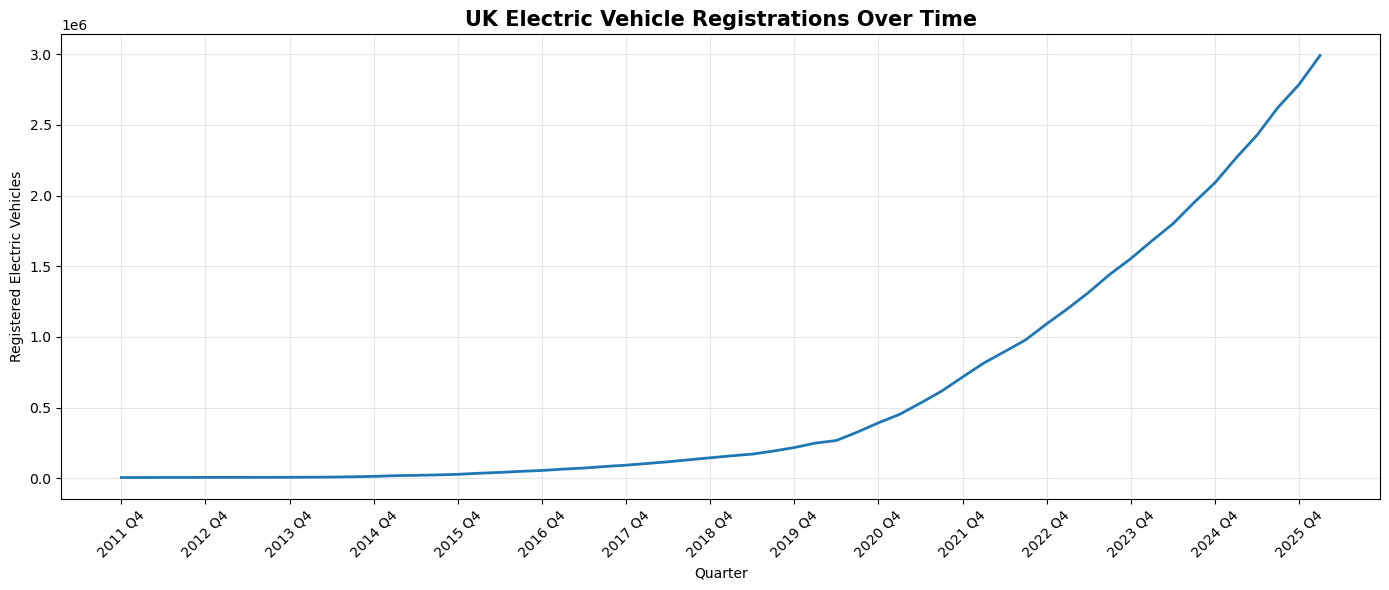

In [8]:
# Plot corrected national EV registration trend

plt.figure(figsize=(14, 6))

plt.plot(
    quarter_columns,
    uk_total.values,
    linewidth=2
)

plt.title(
    "UK Electric Vehicle Registrations Over Time",
    fontsize=15,
    weight="bold"
)

plt.xlabel("Quarter")
plt.ylabel("Registered Electric Vehicles")

plt.xticks(
    ticks=range(0, len(quarter_columns), 4),
    labels=quarter_columns[::4],
    rotation=45
)

plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    figures_folder / "uk_ev_registration_trend.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [9]:
growth = uk_total.pct_change() * 100

print(growth.describe())

count    57.000000
mean     12.206967
std       6.850159
min       0.524836
25%       8.070334
50%      11.150182
75%      15.215129
max      38.580914
dtype: float64


## Comparison of Electric Vehicle Technologies

This section compares quarterly registration trends for battery electric vehicles (BEVs), plug-in hybrid electric vehicles (PHEVs) and range-extended electric vehicles (REEVs).

In [10]:
fuel_types = [
    "Battery electric",
    "Plug-in hybrid electric (petrol)",
    "Range extended electric"
]

fuel_trends = (
    ev_uk[
        (ev_uk["Keepership"] == "Total") &
        (ev_uk["Fuel"].isin(fuel_types))
    ]
    .groupby("Fuel")[quarter_columns]
    .sum()
)

fuel_trends

,2011 Q4,2012 Q1,2012 Q2,2012 Q3,2012 Q4,2013 Q1,2013 Q2,2013 Q3,2013 Q4,2014 Q1,2014 Q2,2014 Q3,2014 Q4,2015 Q1,2015 Q2,2015 Q3,2015 Q4,2016 Q1,2016 Q2,2016 Q3,2016 Q4,2017 Q1,2017 Q2,2017 Q3,2017 Q4,2018 Q1,2018 Q2,2018 Q3,2018 Q4,2019 Q1,2019 Q2,2019 Q3,2019 Q4,2020 Q1,2020 Q2,2020 Q3,2020 Q4,2021 Q1,2021 Q2,2021 Q3,2021 Q4,2022 Q1,2022 Q2,2022 Q3,2022 Q4,2023 Q1,2023 Q2,2023 Q3,2023 Q4,2024 Q1,2024 Q2,2024 Q3,2024 Q4,2025 Q1,2025 Q2,2025 Q3,2025 Q4,2026 Q1
Fuel,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Battery electric,4651.0,4845.0,5111.0,5029.0,5447.0,5453.0,5470.0,5446.0,5681.0,6137.0,6814.0,7299.0,7721.0,8435.0,8501.0,8948.0,9783.0,11011.0,11105.0,12179.0,13113.0,14787.0,15871.0,17557.0,18583.0,21118.0,22684.0,25274.0,28540.0,32995.0,38025.0,49247.0,61344.0,78619.0,90580.0,125144.0,167169.0,200162.0,245759.0,299640.0,372775.0,443575.0,501888.0,565316.0,655504.0,735813.0,822745.0,917209.0,992768.0,1080423.0,1167489.0,1278886.0,1384997.0,1510318.0,1621309.0,1756765.0,1871819.0,2005433.0
Plug-in hybrid electric (petrol),37.0,93.0,129.0,134.0,128.0,158.0,169.0,210.0,244.0,274.0,450.0,1809.0,3819.0,7544.0,9185.0,11193.0,13249.0,18235.0,22501.0,27118.0,30628.0,35377.0,39767.0,45955.0,51435.0,57876.0,64695.0,72221.0,79233.0,84627.0,88100.0,93405.0,102233.0,112541.0,116954.0,135561.0,155008.0,177231.0,207158.0,234248.0,258992.0,286645.0,309668.0,330395.0,355125.0,385259.0,416138.0,451277.0,489570.0,530762.0,568357.0,611788.0,650793.0,705698.0,762564.0,830552.0,877180.0,949804.0
Range extended electric,0.0,23.0,245.0,389.0,495.0,579.0,649.0,717.0,856.0,1132.0,1389.0,1714.0,2117.0,2581.0,2844.0,3208.0,3671.0,4057.0,4335.0,4868.0,5352.0,6039.0,6570.0,7165.0,7560.0,7846.0,8430.0,9349.0,10402.0,10902.0,11386.0,11920.0,12559.0,12888.0,12855.0,13190.0,13394.0,13556.0,14133.0,14758.0,15540.0,16072.0,16784.0,17336.0,17774.0,18139.0,18736.0,19277.0,19786.0,20044.0,20157.0,20387.0,20534.0,20735.0,20957.0,21171.0,21310.0,21317.0


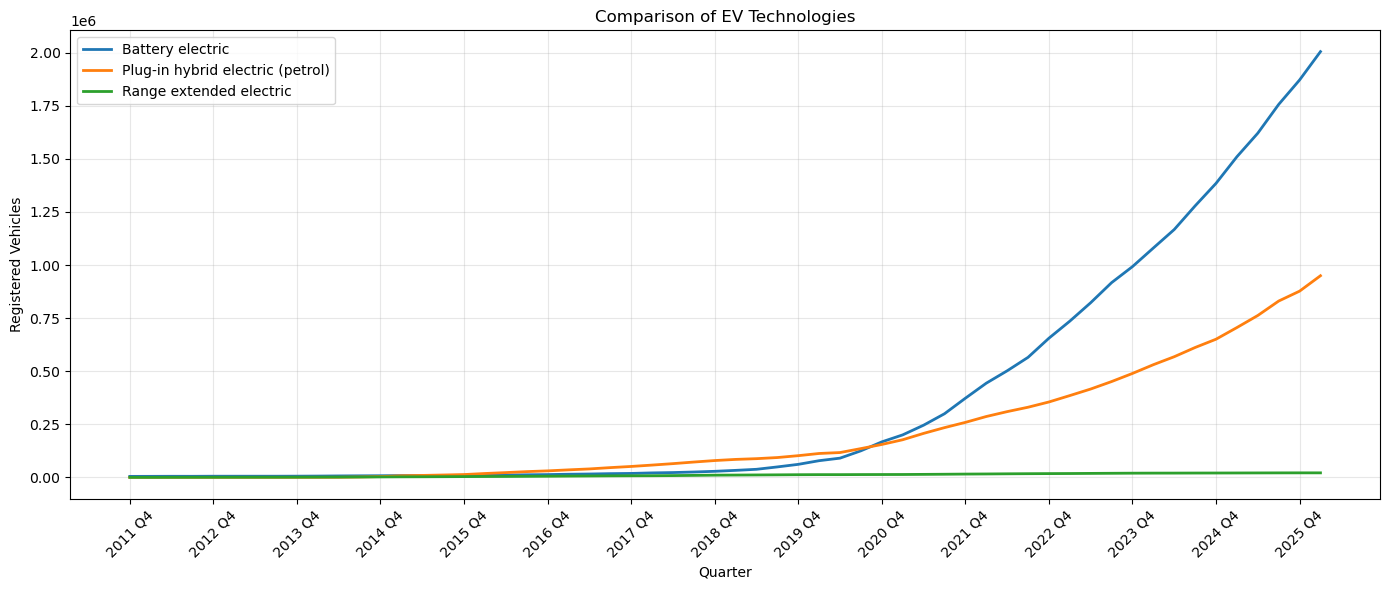

In [11]:
plt.figure(figsize=(14,6))

for fuel in fuel_trends.index:
    plt.plot(
        quarter_columns,
        fuel_trends.loc[fuel],
        linewidth=2,
        label=fuel
    )

tick_positions = range(0, len(quarter_columns), 4)

plt.xticks(
    tick_positions,
    [quarter_columns[i] for i in tick_positions],
    rotation=45
)

plt.title("Comparison of EV Technologies")
plt.xlabel("Quarter")
plt.ylabel("Registered Vehicles")

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    figures_folder / "fuel_type_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Private and Company EV Ownership

This section compares quarterly electric vehicle registrations for private and company keepership. The analysis highlights differences in ownership patterns and how they have changed over time.

In [12]:
keepership_types = [
    "Private",
    "Company"
]

keepership_trends = (
    ev_uk[
        (ev_uk["Fuel"] == "Total") &
        (ev_uk["Keepership"].isin(keepership_types))
    ]
    .groupby("Keepership")[quarter_columns]
    .sum()
)

keepership_trends

,2011 Q4,2012 Q1,2012 Q2,2012 Q3,2012 Q4,2013 Q1,2013 Q2,2013 Q3,2013 Q4,2014 Q1,2014 Q2,2014 Q3,2014 Q4,2015 Q1,2015 Q2,2015 Q3,2015 Q4,2016 Q1,2016 Q2,2016 Q3,2016 Q4,2017 Q1,2017 Q2,2017 Q3,2017 Q4,2018 Q1,2018 Q2,2018 Q3,2018 Q4,2019 Q1,2019 Q2,2019 Q3,2019 Q4,2020 Q1,2020 Q2,2020 Q3,2020 Q4,2021 Q1,2021 Q2,2021 Q3,2021 Q4,2022 Q1,2022 Q2,2022 Q3,2022 Q4,2023 Q1,2023 Q2,2023 Q3,2023 Q4,2024 Q1,2024 Q2,2024 Q3,2024 Q4,2025 Q1,2025 Q2,2025 Q3,2025 Q4,2026 Q1
Keepership,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Company,4182.0,4363.0,4685.0,4845.0,5149.0,5296.0,5300.0,5494.0,5831.0,6366.0,7187.0,9067.0,11580.0,15873.0,17906.0,20155.0,23371.0,29382.0,33336.0,38548.0,42626.0,48152.0,52312.0,57659.0,62379.0,67733.0,73264.0,79121.0,85759.0,90441.0,93522.0,100065.0,111451.0,130028.0,137081.0,169373.0,211872.0,246340.0,287195.0,325945.0,379258.0,431115.0,468464.0,511629.0,587010.0,646709.0,708354.0,777067.0,841827.0,906255.0,962933.0,1033514.0,1114177.0,1200323.0,1270489.0,1355982.0,1422688.0,1494580.0
Private,311.0,294.0,295.0,291.0,291.0,275.0,301.0,319.0,351.0,407.0,450.0,649.0,937.0,1438.0,1512.0,1950.0,2478.0,3428.0,4434.0,5534.0,6815.0,9309.0,11937.0,15730.0,19446.0,24180.0,29874.0,36517.0,43409.0,50690.0,58988.0,71645.0,83770.0,98024.0,105592.0,129586.0,149748.0,172135.0,208051.0,249838.0,291751.0,338719.0,379072.0,414571.0,450005.0,496719.0,547096.0,602631.0,647469.0,707568.0,772943.0,850740.0,914422.0,1006013.0,1103543.0,1216897.0,1307666.0,1440442.0


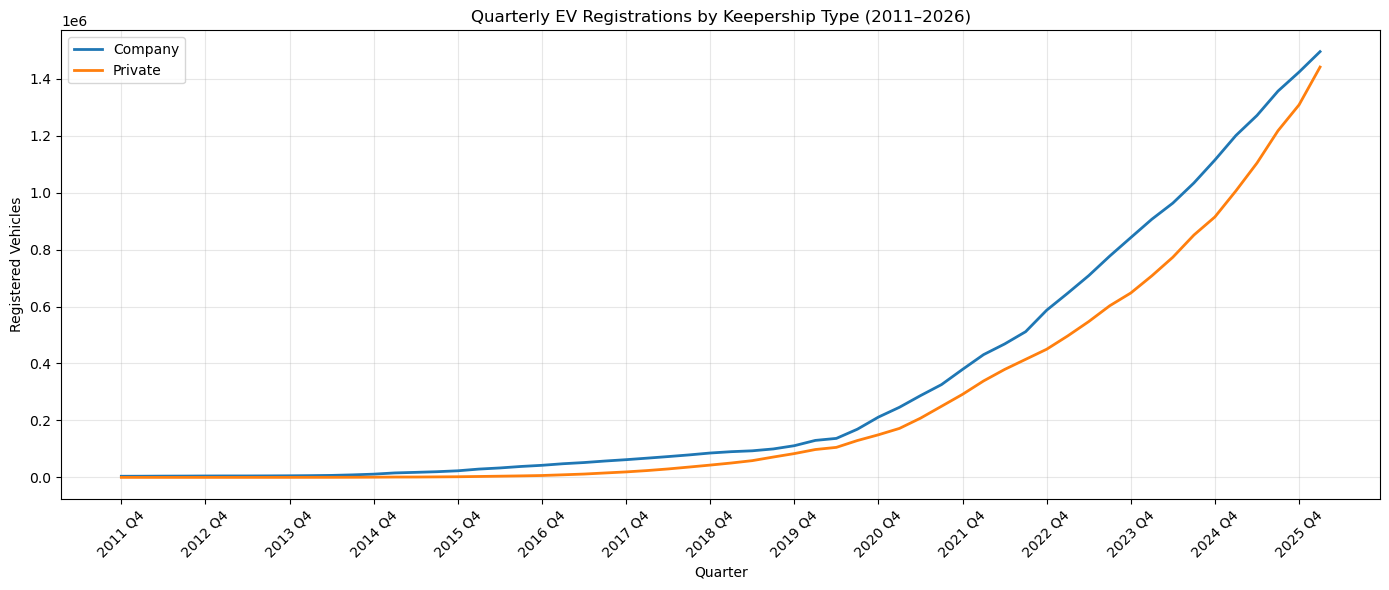

In [13]:
plt.figure(figsize=(14,6))

for owner in keepership_trends.index:
    plt.plot(
        quarter_columns,
        keepership_trends.loc[owner],
        linewidth=2,
        label=owner
    )

tick_positions = range(0, len(quarter_columns), 4)

plt.xticks(
    tick_positions,
    [quarter_columns[i] for i in tick_positions],
    rotation=45
)

plt.title("Quarterly EV Registrations by Keepership Type (2011–2026)")
plt.xlabel("Quarter")
plt.ylabel("Registered Vehicles")

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    figures_folder / "keepership_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Regional EV Adoption Analysis

Regional comparisons are based on the published total vehicle and total keepership records to prevent double-counting. The latest available quarter is used to compare current EV registration levels across Local Authority Districts in England and Wales.

In [14]:
# Select one published total EV count for each geographical area

regional_total = ev_regional[
    (ev_regional["Fuel"] == "Total") &
    (ev_regional["Keepership"] == "Total")
].copy()

print("Rows selected:", len(regional_total))
print("Unique LSOA codes:", regional_total["lsoa_code"].nunique())

Rows selected: 35474
Unique LSOA codes: 35474


In [15]:
# Identify the latest available quarter

latest_quarter = quarter_columns[-1]

# Aggregate the latest EV counts to Local Authority District level

lad_latest_ev = (
    regional_total
    .groupby(["lad_code", "lad_name"], as_index=False)[latest_quarter]
    .sum(min_count=1)
    .rename(columns={latest_quarter: "EV_Registrations"})
)

print("Latest quarter:", latest_quarter)
print("Number of LADs:", len(lad_latest_ev))

lad_latest_ev.head()

Latest quarter: 2026 Q1
Number of LADs: 318


,lad_code,lad_name,EV_Registrations
0,E06000001,Hartlepool,1889.0
1,E06000002,Middlesbrough,2439.0
2,E06000003,Redcar and Cleveland,2501.0
3,E06000004,Stockton-on-Tees,5044.0
4,E06000005,Darlington,5756.0


In [16]:
# Retain one population record for each LSOA

lsoa_population = (
    ev_regional[
        [
            "lsoa_code",
            "lad_code",
            "lad_name",
            "population_2024"
        ]
    ]
    .drop_duplicates(subset="lsoa_code")
)

# Sum LSOA populations to obtain the total population of each LAD

lad_population = (
    lsoa_population
    .groupby(["lad_code", "lad_name"], as_index=False)["population_2024"]
    .sum(min_count=1)
)

lad_population.head()

,lad_code,lad_name,population_2024
0,E06000001,Hartlepool,95773
1,E06000002,Middlesbrough,147681
2,E06000003,Redcar and Cleveland,137848
3,E06000004,Stockton-on-Tees,203490
4,E06000005,Darlington,105124


In [17]:
# Combine the latest EV registrations with LAD population totals

regional_rate = lad_latest_ev.merge(
    lad_population,
    on=["lad_code", "lad_name"],
    how="left",
    validate="one_to_one"
)

regional_rate["EV_per_1000"] = (
    regional_rate["EV_Registrations"] /
    regional_rate["population_2024"]
) * 1000

regional_rate = regional_rate.sort_values(
    "EV_per_1000",
    ascending=False
)

regional_rate[
    [
        "lad_name",
        "EV_Registrations",
        "population_2024",
        "EV_per_1000"
    ]
].head(15)

,lad_name,EV_Registrations,population_2024,EV_per_1000
37,Windsor and Maidenhead,240399.0,158943,1512.485608
28,Peterborough,104309.0,223655,466.383492
39,Milton Keynes,136325.0,305884,445.675485
233,Stockport,119920.0,303929,394.565836
36,Slough,51013.0,167359,304.811812
295,Westminster,52547.0,209996,250.228576
24,South Gloucestershire,64038.0,306332,209.047700
46,Cheshire West and Chester,71285.0,370473,192.416181
115,Rushmoor,15308.0,105751,144.755132
70,Chesterfield,14677.0,106045,138.403508


### Population-adjusted Regional Comparison

EV registrations were divided by the mid-2024 population of each Local Authority District and expressed per 1,000 residents. This provides a population-adjusted comparison between districts of different sizes.

The measure represents registered vehicles rather than individual household ownership. Some districts may record values above 1,000 vehicles per 1,000 residents because company fleets and leased vehicles can be registered at business addresses.

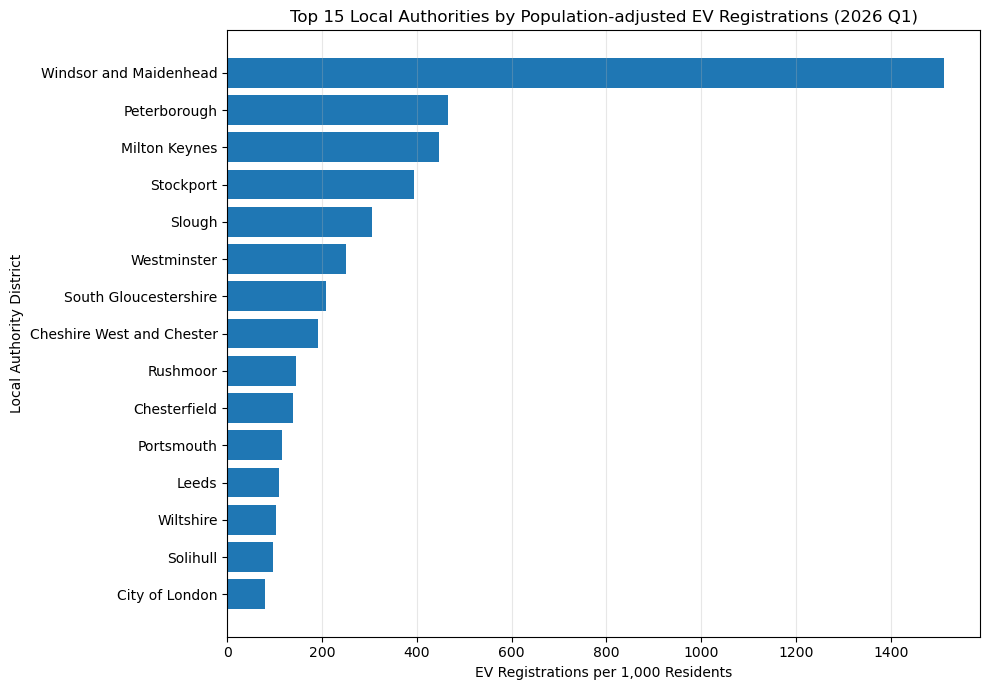

In [18]:
# Select the 15 highest population-adjusted registration rates

top_rate = regional_rate.head(15).copy()

plt.figure(figsize=(10, 7))

plt.barh(
    top_rate["lad_name"][::-1],
    top_rate["EV_per_1000"][::-1]
)

plt.xlabel("EV Registrations per 1,000 Residents")
plt.ylabel("Local Authority District")
plt.title(
    f"Top 15 Local Authorities by Population-adjusted EV Registrations "
    f"({latest_quarter})"
)

plt.grid(axis="x", alpha=0.3)

plt.tight_layout()

plt.savefig(
    figures_folder / "ev_registrations_per_1000_residents.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

The population-adjusted measure represents registered electric vehicles rather than the number of individual residents who own an EV. Values above 1,000 registrations per 1,000 residents may occur where company fleets, leasing businesses or other commercial vehicles are registered within a Local Authority District. Therefore, the results indicate the concentration of vehicle registrations rather than household-level adoption.